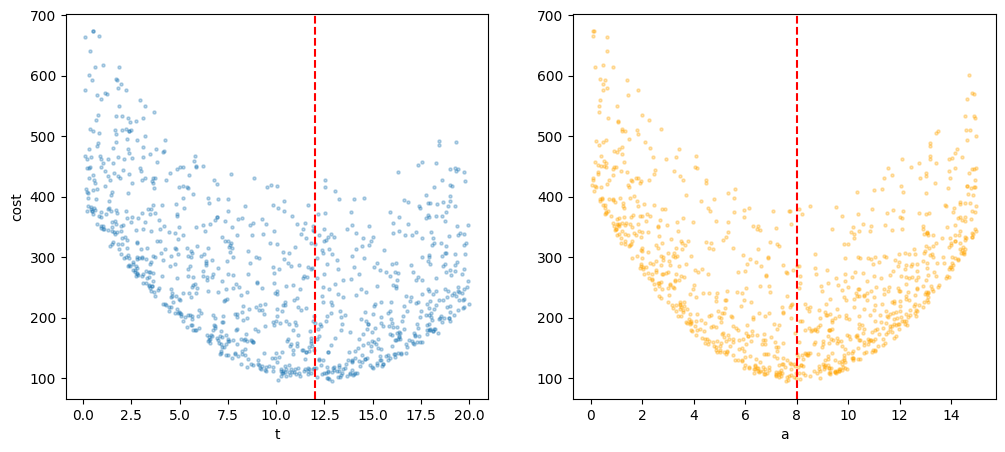

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# part 1: data and noisy scatter
np.random.seed(42)
t = np.random.rand(1000) * 20
a = np.random.rand(1000) * 15
cost = 2 * (t - 12)**2 + 5 * (a - 8)**2 + 100 + np.random.randn(1000) * 5

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(t, cost, alpha=0.3, s=5)
ax[0].axvline(12, color='red', linestyle='--')
ax[0].set_xlabel('t')
ax[0].set_ylabel('cost')

ax[1].scatter(a, cost, alpha=0.3, s=5, c='orange')
ax[1].axvline(8, color='red', linestyle='--')
ax[1].set_xlabel('a')

plt.show()

part 2 gd: 12.0 8.000000033526929


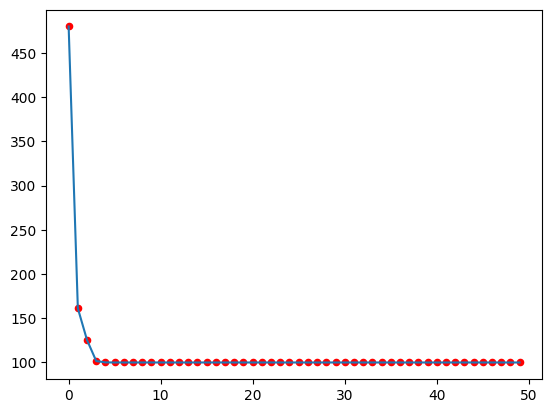

In [24]:
def f(t, a):
    return 2*(t-12)**2 + 5*(a-8)**2 + 100

def grad(t, a):
    return 4*(t-12), 10*(a-8)

cur_t, cur_a = 2.0, 2.0
hist = []

for _ in range(50):
    c = f(cur_t, cur_a)
    hist.append(c)
    dt, da = grad(cur_t, cur_a)

    lr = 0.25
    while True:
        nt = cur_t - lr * dt
        na = cur_a - lr * da
        nc = f(nt, na)

        if nc < c or lr < 1e-7:
            cur_t, cur_a = nt, na
            break
        lr *= 0.5

print("part 2 gd:", cur_t, cur_a)
plt.scatter(range(len(hist)), hist, color='red', s=20)
plt.plot(hist)
plt.show()

part 3 mb: 30.12982642961875 14.503524645119104
part 3 scipy: [12.00000037  8.00000018] 7


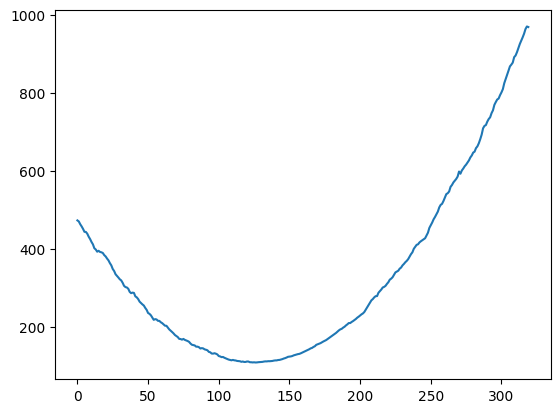

In [25]:
t_mb, a_mb = 2.0, 2.0
mb_hist = []

for epoch in range(20):
    idx = np.random.permutation(1000)
    t_shuf = t[idx]
    a_shuf = a[idx]

    for i in range(0, 1000, 64):
        tb = t_shuf[i:i+64]
        ab = a_shuf[i:i+64]

        dt = np.mean(4*(tb-12))
        da = np.mean(10*(ab-8))

        t_mb -= 0.01 * dt
        a_mb -= 0.01 * da

        mb_hist.append(f(t_mb, a_mb))

def wrap(x):
    return f(x[0], x[1])

res = minimize(wrap, [2.0, 2.0], method='BFGS')
print("part 3 mb:", t_mb, a_mb)
print("part 3 scipy:", res.x, res.nit)

plt.plot(mb_hist)
plt.show()

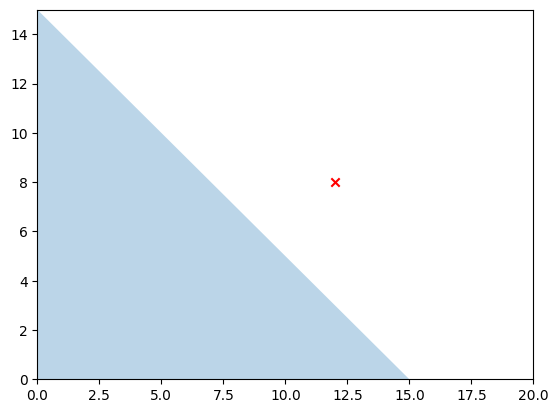

In [26]:
t_line = np.linspace(0, 15, 100)
a_line = 15 - t_line

plt.fill_between(t_line, 0, a_line, alpha=0.3)
plt.scatter(12, 8, c='red', marker='x')
plt.xlim(0, 20)
plt.ylim(0, 15)
plt.show()

# Text Cell Analysis: The Golden Rule (Min-Maxing the Build)

Think of the constraint limit ($T + A \le 15$) like a hard level cap for a specific dungeon or PvP bracket. Our unconstrained optimum is $(12, 8)$, meaning our absolute ideal, highest-efficiency build requires 12 points in Thrust and 8 in Wing Area. But that requires 20 total points, which puts us over the level cap. It sits completely outside the "feasible region" (the allowed stats).Because our ideal build is out of bounds, the Geometric Optimality Condition (The Golden Rule) kicks in. It states that our best possible legal build must sit exactly on the level cap boundary line ($T + A = 15$).

Here is why: We want to move in a Descent Direction (the path that points straight towards our ideal 12/8 build to reduce the cost function). However, the game engine restricts us to Feasible Directions (we must stay inside the triangle where total points are 15 or less). The absolute best compromise—where the stats get as close to our ideal target as the game mathematically allows without breaking the rules—is right on the edge of the boundary line. You have to push the stats right up to the cap.